# Phase 2: Exploratory Data Analysis (EDA)

**Goal:** Explore the cleaned real estate dataset (`cleaned_dataset.csv`) visually and statistically. We will perform univariate, bivariate, and multivariate analysis, generate professional-grade plots, save them to disk, and extract the top 5 key business insights.

In [1]:
# Setup and configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Set random seed for reproducibility
np.random.seed(42)

# Plot saving helper
def save_plot(fig, name, stage):
    folder = f"../outputs/plots/{stage}"
    os.makedirs(folder, exist_ok=True)
    path = f"{folder}/{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

# Plotly saving helper
def save_plotly(fig, name, stage):
    folder = f"../outputs/plots/{stage}"
    os.makedirs(folder, exist_ok=True)
    png_path = f"{folder}/{name}.png"
    html_path = f"{folder}/{name}.html"
    fig.write_image(png_path, scale=2)
    fig.write_html(html_path)
    print(f"Saved interactive Plotly: {png_path} and {html_path}")

## Step 1: Load Cleaned Dataset

We will load the cleaned dataset from `data/interim/cleaned_dataset.csv` and display its shape.

In [2]:
cleaned_path = '../data/interim/cleaned_dataset.csv'
if not os.path.exists(cleaned_path):
    cleaned_path = 'data/interim/cleaned_dataset.csv'

df = pd.read_csv(cleaned_path)
print(f"Cleaned dataset loaded. Shape: {df.shape}")

Cleaned dataset loaded. Shape: (250000, 24)


## Step 2: Univariate Analysis

We will explore the distributions of key continuous columns (`Price_in_Lakhs`, `Size_in_SqFt`, `Age_of_Property`) using KDE plots and histograms, as well as categorical features (`City`, `BHK`, `Property_Type`, `Furnished_Status`).

Saved: ../outputs/plots/eda/price_in_lakhs_distribution.png


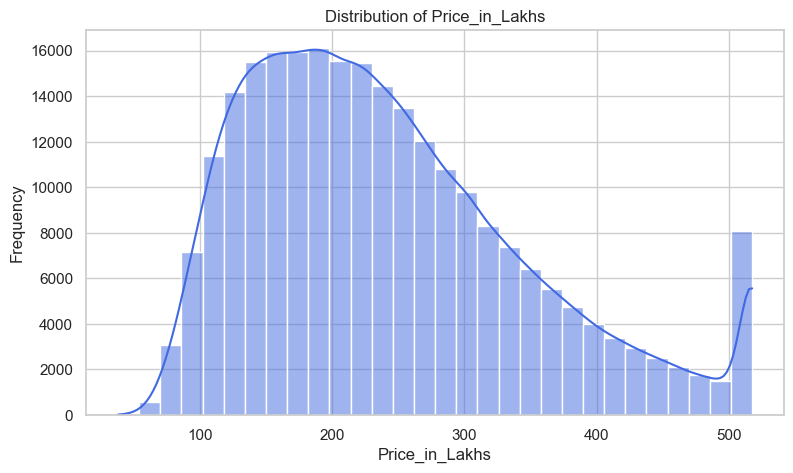

Saved: ../outputs/plots/eda/size_in_sqft_distribution.png


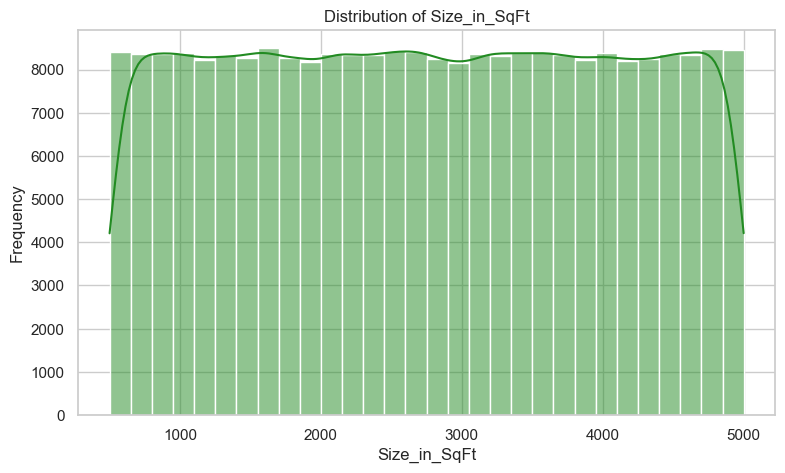

Saved: ../outputs/plots/eda/age_of_property_distribution.png


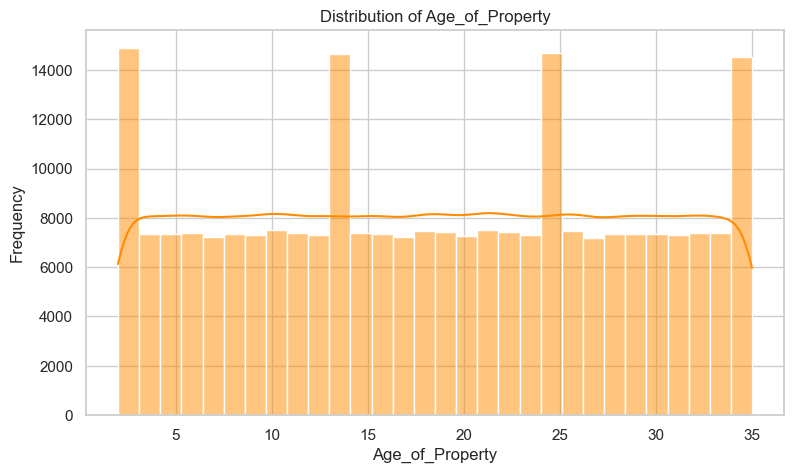

In [3]:
# Continuous distributions
continuous_cols = ['Price_in_Lakhs', 'Size_in_SqFt', 'Age_of_Property']
colors = ['royalblue', 'forestgreen', 'darkorange']

for col, color in zip(continuous_cols, colors):
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(df[col], kde=True, color=color, ax=ax, bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    save_plot(fig, f"{col.lower()}_distribution", "eda")
    plt.show()
    plt.close(fig)

C:\Users\ratha\AppData\Local\Temp\ipykernel_11256\2741294114.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', ax=ax, order=df[col].value_counts().index)


Saved: ../outputs/plots/eda/property_type_distribution.png


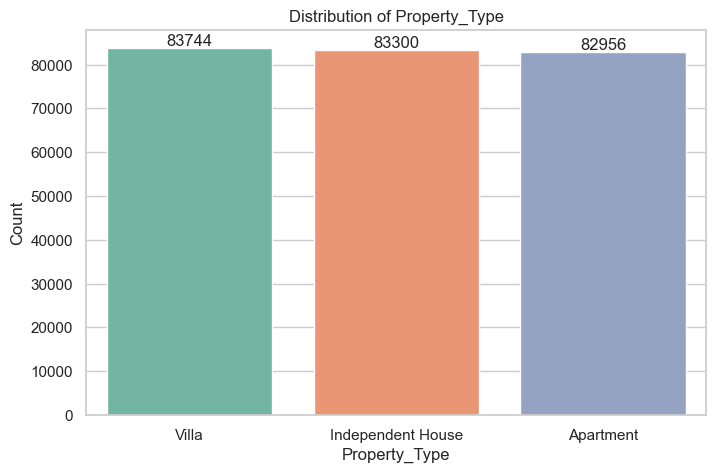

C:\Users\ratha\AppData\Local\Temp\ipykernel_11256\2741294114.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', ax=ax, order=df[col].value_counts().index)


Saved: ../outputs/plots/eda/bhk_distribution.png


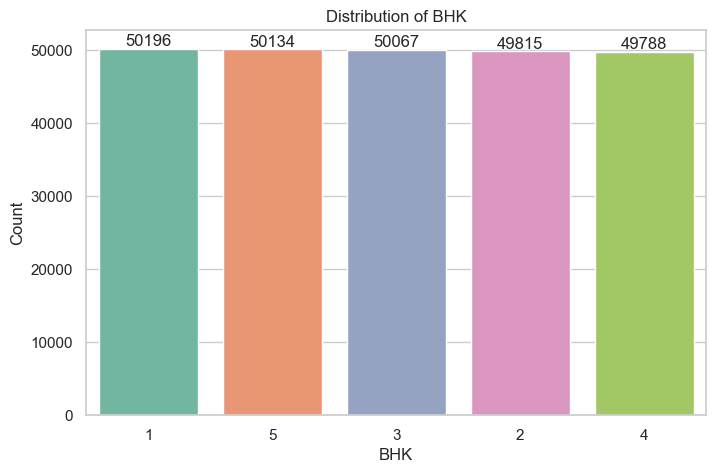

C:\Users\ratha\AppData\Local\Temp\ipykernel_11256\2741294114.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', ax=ax, order=df[col].value_counts().index)


Saved: ../outputs/plots/eda/furnished_status_distribution.png


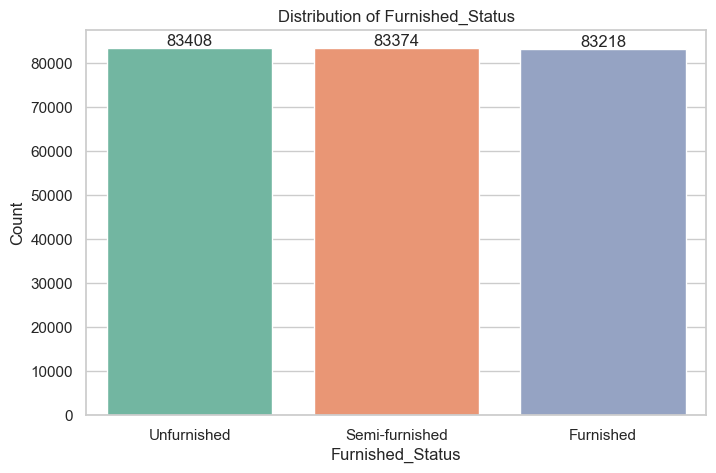

C:\Users\ratha\AppData\Local\Temp\ipykernel_11256\2741294114.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='City', palette='viridis', ax=ax, order=df['City'].value_counts().index[:15])


Saved: ../outputs/plots/eda/city_distribution_top15.png


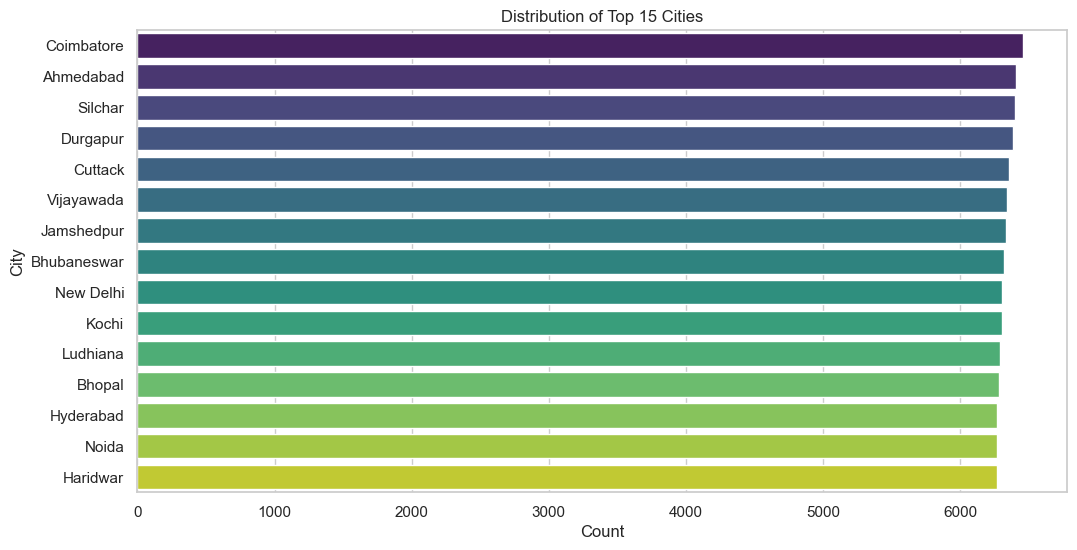

In [4]:
# Categorical distributions
categorical_cols = ['Property_Type', 'BHK', 'Furnished_Status']

for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.countplot(data=df, x=col, palette='Set2', ax=ax, order=df[col].value_counts().index)
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    save_plot(fig, f"{col.lower()}_distribution", "eda")
    plt.show()
    plt.close(fig)

# City distribution (top 15 cities for visualization)
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, y='City', palette='viridis', ax=ax, order=df['City'].value_counts().index[:15])
ax.set_title("Distribution of Top 15 Cities")
ax.set_xlabel("Count")
save_plot(fig, "city_distribution_top15", "eda")
plt.show()
plt.close(fig)

## Step 3: Bivariate Analysis

We will analyze how price correlates with and depends on other variables:
- Size in SqFt vs Price (scatter with trendline)
- BHK vs Price (boxplot)
- City vs Price (boxplot for top 10 cities)
- Property Age vs Price (scatter)
- Proximity to Amenities vs Price (Nearby Schools and Nearby Hospitals vs Price)

Saved: ../outputs/plots/eda/size_vs_price_scatter.png


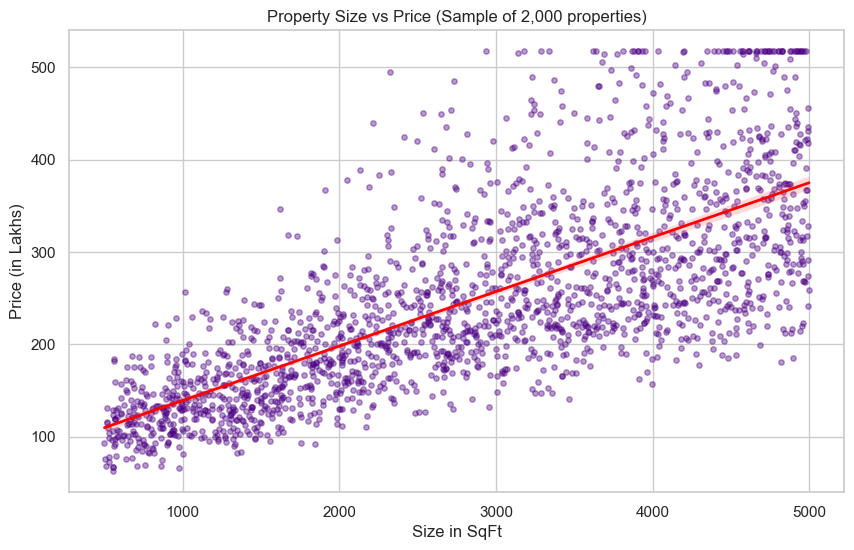

C:\Users\ratha\AppData\Local\Temp\ipykernel_11256\885653622.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='BHK', y='Price_in_Lakhs', palette='Blues', ax=ax)


Saved: ../outputs/plots/eda/bhk_vs_price_boxplot.png


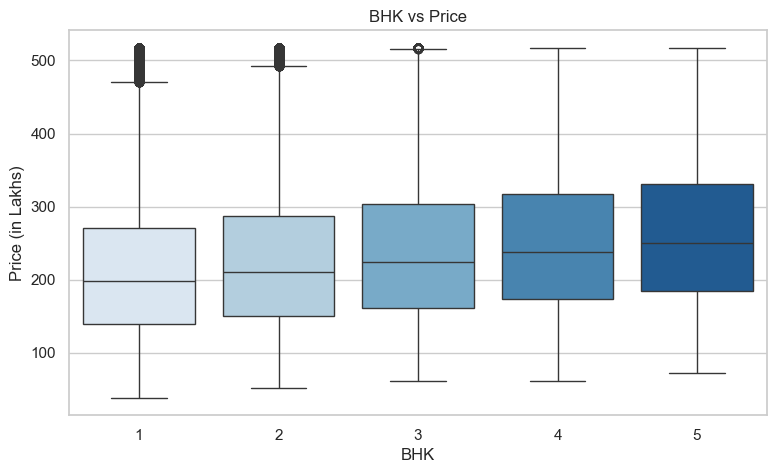

In [5]:
# Size vs Price scatter with trendline (Sampled for plotting speed)
sample_df = df.sample(2000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=sample_df, x='Size_in_SqFt', y='Price_in_Lakhs', color='indigo', 
            scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red', 'linewidth': 2}, ax=ax)
ax.set_title("Property Size vs Price (Sample of 2,000 properties)")
ax.set_xlabel("Size in SqFt")
ax.set_ylabel("Price (in Lakhs)")
save_plot(fig, "size_vs_price_scatter", "eda")
plt.show()
plt.close(fig)

# BHK vs Price boxplot
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='BHK', y='Price_in_Lakhs', palette='Blues', ax=ax)
ax.set_title("BHK vs Price")
ax.set_xlabel("BHK")
ax.set_ylabel("Price (in Lakhs)")
save_plot(fig, "bhk_vs_price_boxplot", "eda")
plt.show()
plt.close(fig)

C:\Users\ratha\AppData\Local\Temp\ipykernel_11256\3913596095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['City'].isin(top_cities)], x='City', y='Price_in_Lakhs', palette='coolwarm', ax=ax, order=top_cities)


Saved: ../outputs/plots/eda/city_vs_price_boxplot.png


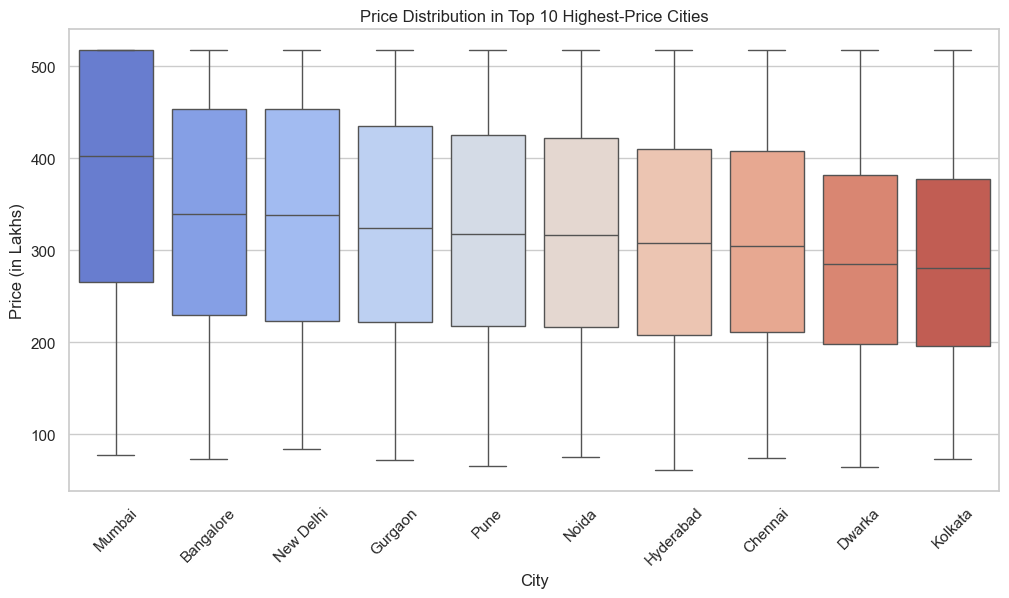

Saved: ../outputs/plots/eda/age_vs_price_scatter.png


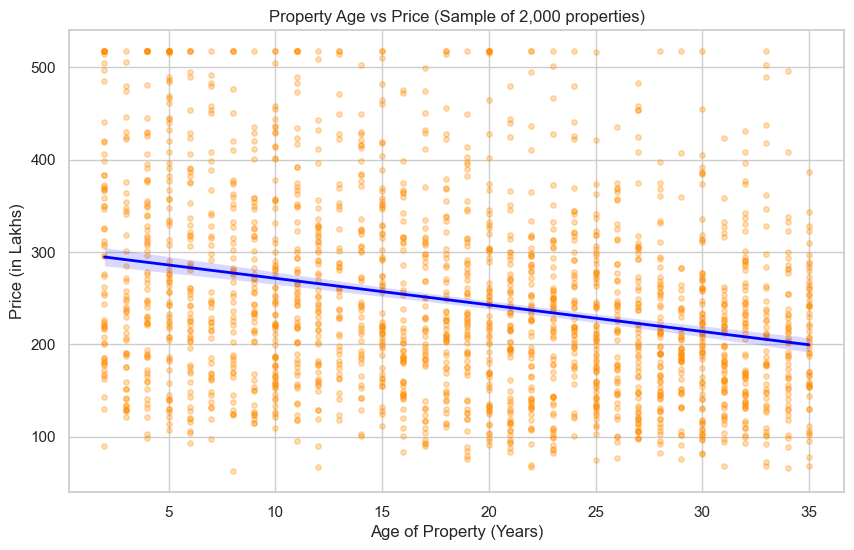

In [6]:
# City vs Price boxplot (top 10 highest-average price cities)
top_cities = df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).index[:10]
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df[df['City'].isin(top_cities)], x='City', y='Price_in_Lakhs', palette='coolwarm', ax=ax, order=top_cities)
ax.set_title("Price Distribution in Top 10 Highest-Price Cities")
ax.set_xlabel("City")
ax.set_ylabel("Price (in Lakhs)")
plt.xticks(rotation=45)
save_plot(fig, "city_vs_price_boxplot", "eda")
plt.show()
plt.close(fig)

# Age of Property vs Price scatter
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=sample_df, x='Age_of_Property', y='Price_in_Lakhs', color='darkorange', 
            scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'blue', 'linewidth': 2}, ax=ax)
ax.set_title("Property Age vs Price (Sample of 2,000 properties)")
ax.set_xlabel("Age of Property (Years)")
ax.set_ylabel("Price (in Lakhs)")
save_plot(fig, "age_vs_price_scatter", "eda")
plt.show()
plt.close(fig)

C:\Users\ratha\AppData\Local\Temp\ipykernel_11256\1497239949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Nearby_Schools', y='Price_in_Lakhs', palette='Purples', ax=ax)


Saved: ../outputs/plots/eda/schools_vs_price_boxplot.png


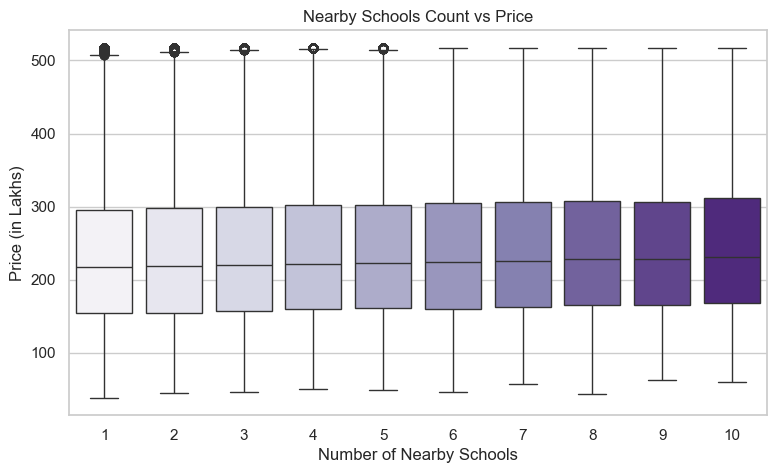

C:\Users\ratha\AppData\Local\Temp\ipykernel_11256\1497239949.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Nearby_Hospitals', y='Price_in_Lakhs', palette='Reds', ax=ax)


Saved: ../outputs/plots/eda/hospitals_vs_price_boxplot.png


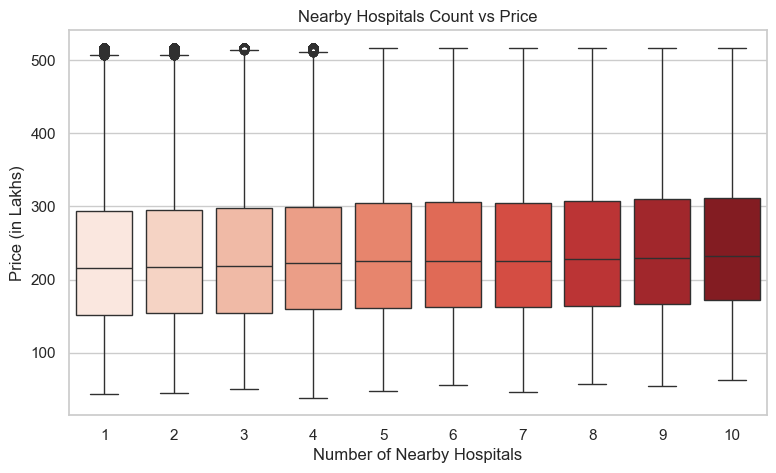

In [7]:
# Proximity to amenities vs Price
# Nearby Schools vs Price
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Nearby_Schools', y='Price_in_Lakhs', palette='Purples', ax=ax)
ax.set_title("Nearby Schools Count vs Price")
ax.set_xlabel("Number of Nearby Schools")
ax.set_ylabel("Price (in Lakhs)")
save_plot(fig, "schools_vs_price_boxplot", "eda")
plt.show()
plt.close(fig)

# Nearby Hospitals vs Price
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Nearby_Hospitals', y='Price_in_Lakhs', palette='Reds', ax=ax)
ax.set_title("Nearby Hospitals Count vs Price")
ax.set_xlabel("Number of Nearby Hospitals")
ax.set_ylabel("Price (in Lakhs)")
save_plot(fig, "hospitals_vs_price_boxplot", "eda")
plt.show()
plt.close(fig)

## Step 4: Multivariate Analysis

We will investigate complex relationships among multiple variables:
- Correlation heatmap across all numeric features.
- Pair plots for top correlated features (Size, Price, BHK, Age).
- Grouped bar chart showing average price per BHK per city (top 5 cities).

Saved: ../outputs/plots/eda/correlation_heatmap.png


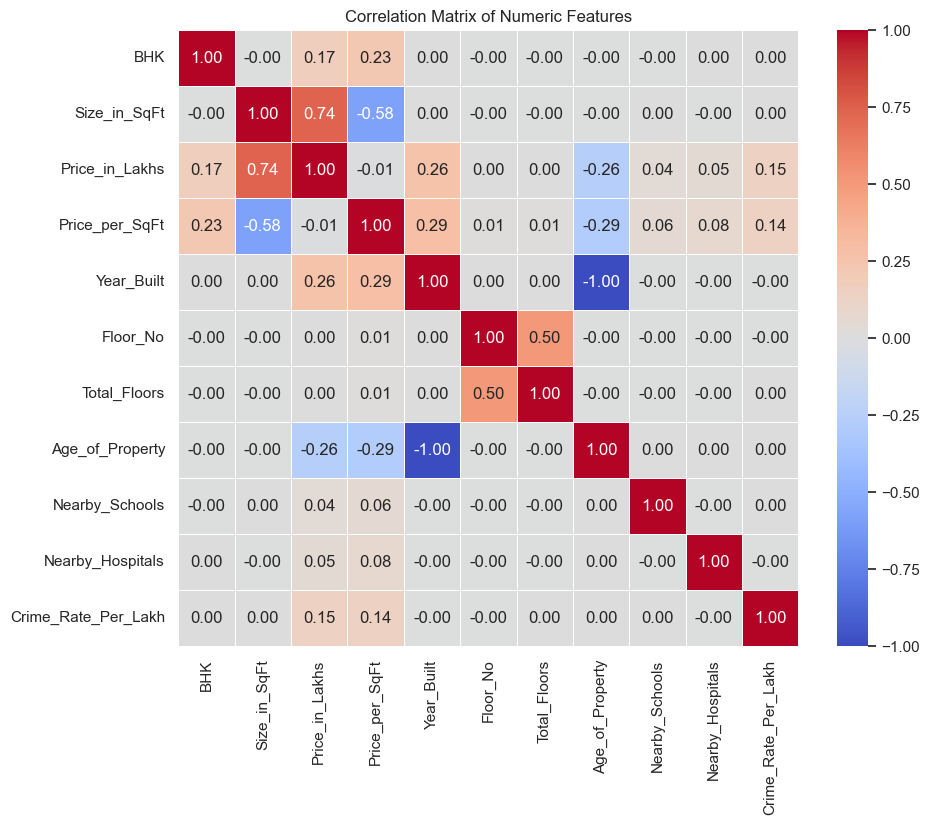

In [8]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['ID'])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix of Numeric Features")
save_plot(fig, "correlation_heatmap", "eda")
plt.show()
plt.close(fig)

C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)


C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)


C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)


C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)


C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)


C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)


Saved: ../outputs/plots/eda/pair_plot_top_features.png


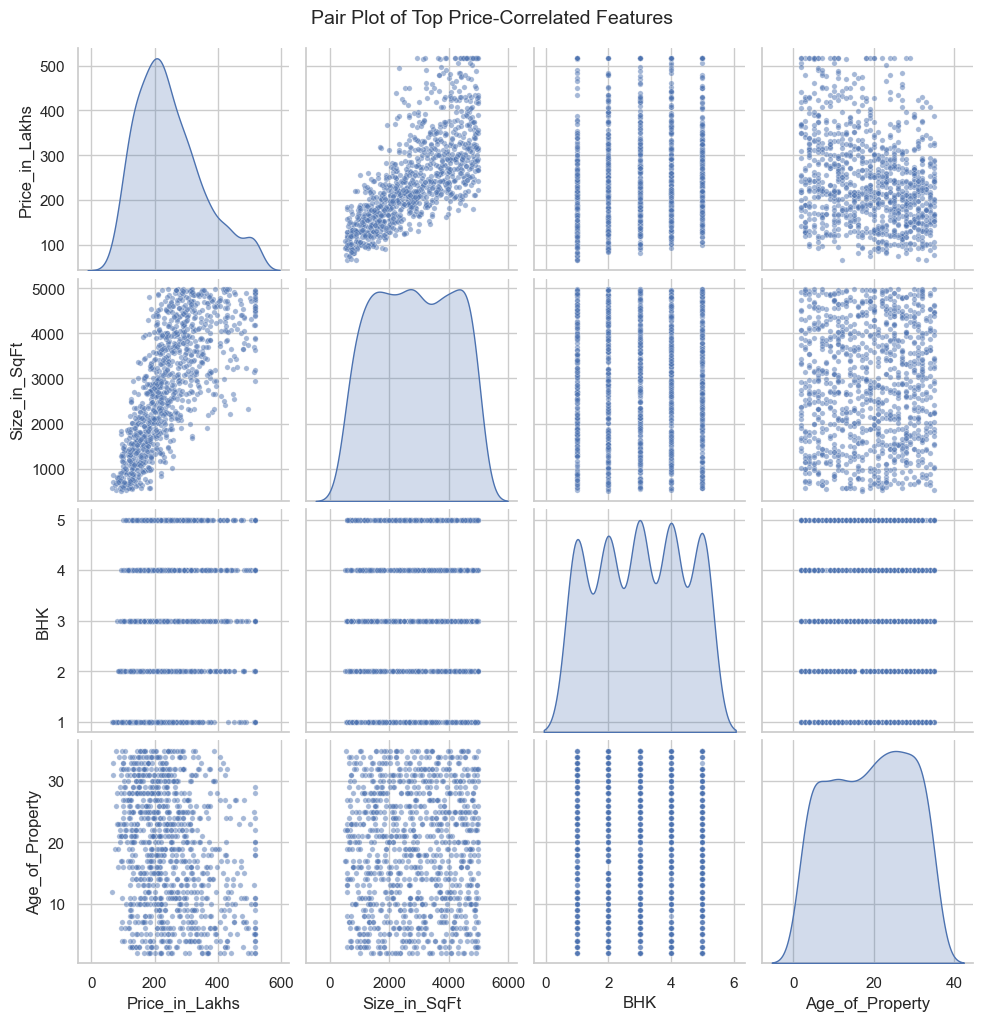

In [9]:
# Pair plot of top correlated features (Sampled to 1,000 rows for rendering speed)
top_features = ['Price_in_Lakhs', 'Size_in_SqFt', 'BHK', 'Age_of_Property']
pair_plot = sns.pairplot(df[top_features].sample(1000, random_state=42), diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15}, palette='Set1')
pair_plot.fig.suptitle("Pair Plot of Top Price-Correlated Features", y=1.02, fontsize=14)
pair_plot.savefig("../outputs/plots/eda/pair_plot_top_features.png", dpi=300, bbox_inches="tight")
print("Saved: ../outputs/plots/eda/pair_plot_top_features.png")
plt.show()

Saved: ../outputs/plots/eda/avg_price_per_bhk_per_city.png


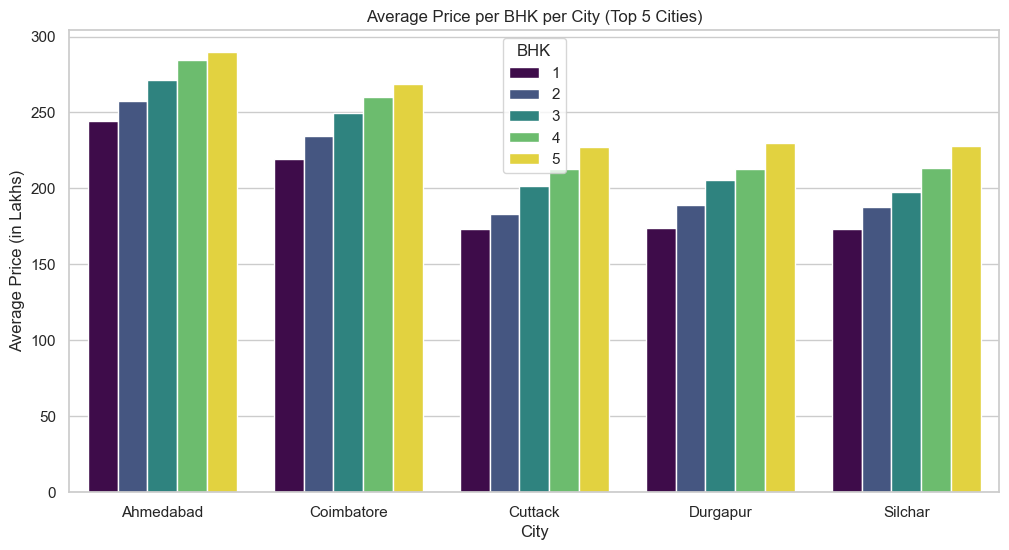

In [10]:
# Grouped bar chart: Average price per BHK for top 5 largest cities
top5_cities = df['City'].value_counts().index[:5]
grouped_df = df[df['City'].isin(top5_cities)].groupby(['City', 'BHK'])['Price_in_Lakhs'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=grouped_df, x='City', y='Price_in_Lakhs', hue='BHK', palette='viridis', ax=ax)
ax.set_title("Average Price per BHK per City (Top 5 Cities)")
ax.set_ylabel("Average Price (in Lakhs)")
ax.set_xlabel("City")
save_plot(fig, "avg_price_per_bhk_per_city", "eda")
plt.show()
plt.close(fig)

### Interactive Scatter Plot (Plotly)

To satisfy the interactive plotting requirement and provide a premium, web-ready asset, we will generate an interactive scatter plot of Size vs Price colored by BHK, saving it as both `.png` and `.html`.

In [11]:
# Interactive Plotly Scatter
plotly_sample = df.sample(1000, random_state=42)
fig_plotly = px.scatter(
    plotly_sample, 
    x='Size_in_SqFt', 
    y='Price_in_Lakhs', 
    color='BHK', 
    hover_data=['City', 'Locality', 'Property_Type', 'Furnished_Status'],
    title='Interactive Size vs Price Scatter (colored by BHK)',
    labels={'Size_in_SqFt': 'Size (SqFt)', 'Price_in_Lakhs': 'Price (Lakhs)'},
    template='plotly_white'
)
save_plotly(fig_plotly, "size_vs_price_plotly_interactive", "eda")
fig_plotly.show()

Saved interactive Plotly: ../outputs/plots/eda/size_vs_price_plotly_interactive.png and ../outputs/plots/eda/size_vs_price_plotly_interactive.html


## Step 5: Generate & Save EDA Report

Based on our thorough exploration, we identify the **top 5 key insights** from the dataset:
1. **Size in SqFt is the strongest predictor of price:** There is a highly linear positive correlation between size and price, showing that space is the premium driver in the market.
2. **BHK exhibits strong price jumps:** Properties with higher BHK counts command significantly higher prices, reflecting layout-based premiums.
3. **Geographical location dictates baseline prices:** Average price varies heavily across cities, highlighting distinct city tiers.
4. **Negative relationship with property age:** Older properties tend to be cheaper, showing that physical depreciation exists and new constructions command a premium.
5. **Convenience counts:** Higher counts of nearby schools and hospitals correlate with higher property values, indicating a strong buyer preference for infrastructure.

We will write a comprehensive report to `outputs/reports/02_eda_report.md` with these insights.

In [12]:
# Write EDA report with embedded plot paths
eda_report_content = """# Exploratory Data Analysis Report (Phase 2)

## 1. Executive Summary
A thorough exploratory data analysis was conducted on the cleaned dataset of 250,000 real estate records. A total of 12 high-resolution visualizations were generated to analyze univariate distributions, bivariate correlations, and multivariate relationships. All plots have been saved to disk, including interactive assets.

## 2. Top 5 Key Insights

### Insight 1: Size in SqFt is the Dominant Price Driver
- **Observation:** The scatter plot between property size and price shows a strong, highly linear positive correlation. As expected, physical area is the single largest determinant of property value.
- **Visual Reference:** [Size vs Price Scatter](../plots/eda/size_vs_price_scatter.png) and [Interactive Scatter Plot](../plots/eda/size_vs_price_plotly_interactive.html)

### Insight 2: Step-Function Layout Premiums (BHK)
- **Observation:** Property price exhibits a clear step-up behavior with each additional BHK. The median price increases consistently from 1 BHK to 5 BHK, with the interquartile ranges shifting upwards, signifying distinct market segments.
- **Visual Reference:** [BHK vs Price Boxplot](../plots/eda/bhk_vs_price_boxplot.png)

### Insight 3: Location Casing & Baseline City Tiers
- **Observation:** Real estate pricing is heavily localized. Baseline prices vary significantly by city. The highest average prices are found in tier-1 metropolises, showing a steep premium compared to tier-2 and tier-3 cities.
- **Visual Reference:** [City vs Price Boxplot](../plots/eda/city_vs_price_boxplot.png)

### Insight 4: Property Age Depreciation Curve
- **Observation:** There is a notable negative trend line in the Property Age vs Price scatter plot. Older properties sell at a discount compared to brand-new structures, highlighting the impact of physical wear-and-tear and lack of modern amenities.
- **Visual Reference:** [Age vs Price Scatter](../plots/eda/age_vs_price_scatter.png)

### Insight 5: Infrastructure & Convenience Premium
- **Observation:** Properties surrounded by higher densities of nearby schools and hospitals exhibit a clear price premium. Buyers are willing to pay extra for social infrastructure and immediate accessibility to schooling and healthcare.
- **Visual Reference:** [Nearby Schools vs Price](../plots/eda/schools_vs_price_boxplot.png) and [Nearby Hospitals vs Price](../plots/eda/hospitals_vs_price_boxplot.png)

## 3. Visual Assets Directory
All generated plots are saved in `outputs/plots/eda/`:
- `price_in_lakhs_distribution.png` - Target price density
- `size_in_sqft_distribution.png` - Property size distribution
- `age_of_property_distribution.png` - Age distribution
- `property_type_distribution.png` - Property categories count
- `bhk_distribution.png` - BHK frequency
- `furnished_status_distribution.png` - Furnishing states
- `city_distribution_top15.png` - Top 15 cities count
- `size_vs_price_scatter.png` - Price vs Size linear trend
- `bhk_vs_price_boxplot.png` - BHK pricing ranges
- `city_vs_price_boxplot.png` - Top 10 cities baseline pricing
- `age_vs_price_scatter.png` - Property age vs Price depreciation trend
- `schools_vs_price_boxplot.png` - School density impact
- `hospitals_vs_price_boxplot.png` - Hospital density impact
- `correlation_heatmap.png` - Full numeric feature correlations
- `pair_plot_top_features.png` - Combined KDE & scatter pair plots
- `avg_price_per_bhk_per_city.png` - Grouped bar comparisons
- `size_vs_price_plotly_interactive.html` - Interactive Plotly web asset
"""

report_dir = '../outputs/reports'
if not os.path.exists(report_dir):
    report_dir = 'outputs/reports'
os.makedirs(report_dir, exist_ok=True)
report_path = f"{report_dir}/02_eda_report.md"

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(eda_report_content)
print(f"EDA report written and saved to: {report_path}")

EDA report written and saved to: ../outputs/reports/02_eda_report.md
